# 🎆 Happy New Year 2026!
# Learn Python, NumPy, and Matplotlib with Fireworks
---
### Sumudu Tennakoon, PhD
#### **www.datasciencefoundations.com**
---

Welcome to this hands-on creative coding project!. In this notebook, we’ll **build a fireworks animation step by step**.

You will learn:

- How to use **NumPy** for numerical computing
- How to use **Matplotlib** for plots and animations and adding trails and particle systems  
- How simple **physics** (velocity + gravity) creates realistic motion
- How to assemble everything into a **Happy New Year 2026** greeting
- How to **Export Python animations** as GIF/MP4  

Run each code cell, observe the output, and watch the scene come alive!

## 1. Setup: imports and basic figure
### 1.1 Imports

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# Make plots appear inside the notebook
%matplotlib inline

### 1.2 A simple empty night sky

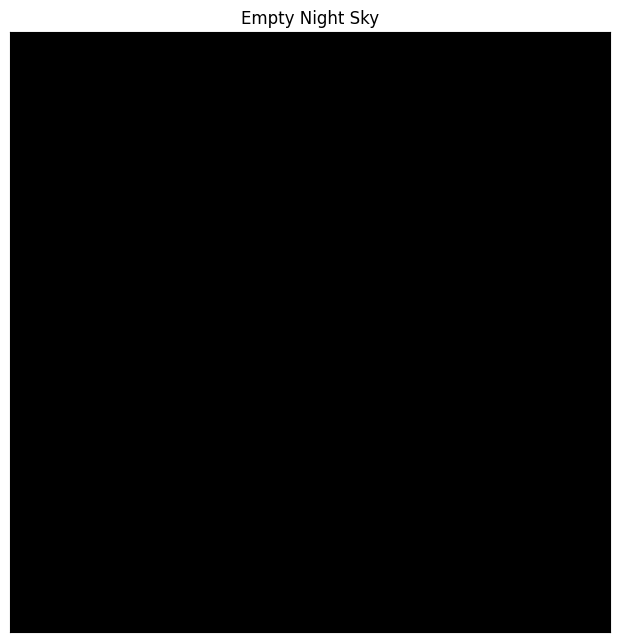

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.

ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)

# Hide axis ticks
ax.set_xticks([])
ax.set_yticks([])

plt.title("Empty Night Sky")
plt.show()

Reflection Questions
- Why do we hide the axis ticks for this visualization
- What does `set_facecolor("black")` help us simulate
- Why do we choose a square figure `(6x6)` instead of a rectangle

## 2. First sparks
### 2.1 Turning sparks into moving particles
Generate a circular burst once

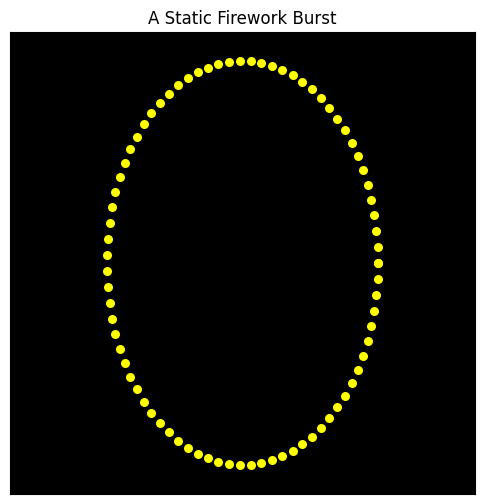

In [41]:
# Number of sparks
n = 80

# Explosion center
x0 = 0
y0 = 4

# Angles from 0 to 2π for each spark
angles = np.linspace(0, 2 * np.pi, n)

# Speed (just for scaling the radius)
speed = 3.5

# Compute positions of each spark
x = x0 + np.cos(angles) * speed
y = y0 + np.sin(angles) * speed

# Screate figure and add visual limits (cooridnates, etc.)
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

# Add data to visualize as a scatter plot
ax.scatter(x, y, color="yellow", s=30)

# Add title to the plot display
plt.title("A Static Firework Burst")
plt.show()

Reflection Questions
- Why do we use `np.linspace` instead of a Python loop
- How do `cos` and `sin` help create a circular pattern
- What happens if you change `speed` to a larger or smaller number


### 2.2 Turning sparks into moving particles
Define a single firework with velocity

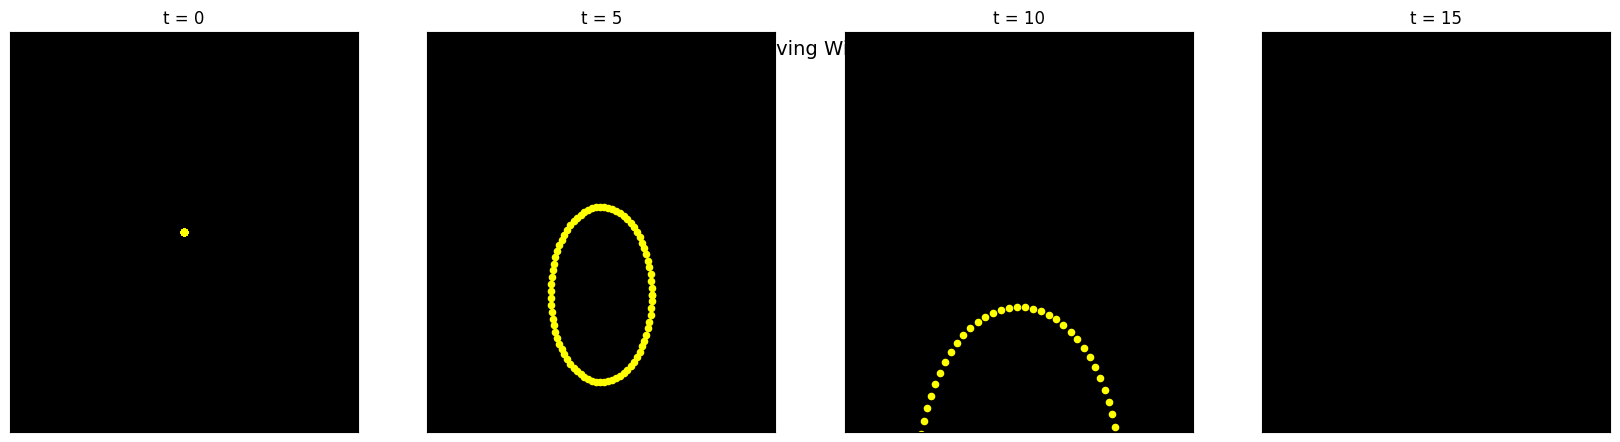

In [42]:
n = 80
x0 = 0
y0 = 4

angles = np.linspace(0, 2 * np.pi, n)
speed = 3.5

# Initial positions
x = np.full(n, x0)
y = np.full(n, y0)

# Velocities
vx = np.cos(angles) * speed
vy = np.sin(angles) * speed

gravity = -0.1  # constant downward pull

# Let's simulate motion for a few steps and plot snapshots
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Sparks Moving With Gravity", fontsize=14)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.

for step, ax in enumerate(axes):
    ax.set_facecolor("black")
    ax.set_xlim(-6, 6)
    ax.set_ylim(0, 8)
    ax.set_xticks([])
    ax.set_yticks([])

    # Copy positions so each subplot shows a later time
    x_step = x + vx * 0.1 * (step * 5)
    y_step = y + vy * 0.1 * (step * 5) + 0.5 * gravity * (step * 5)**2

    ax.scatter(x_step, y_step, color="yellow", s=20)
    ax.set_title(f"t = {step * 5}")

plt.show()

Reflection Questions
- Why does gravity only affect the y‑velocity
- What does multiplying by `0.1` do in the motion equation
- Why do sparks spread out more over time


### 2.3 Adding Colors (Random color)
Run the code cell multiple times to see color change randomly

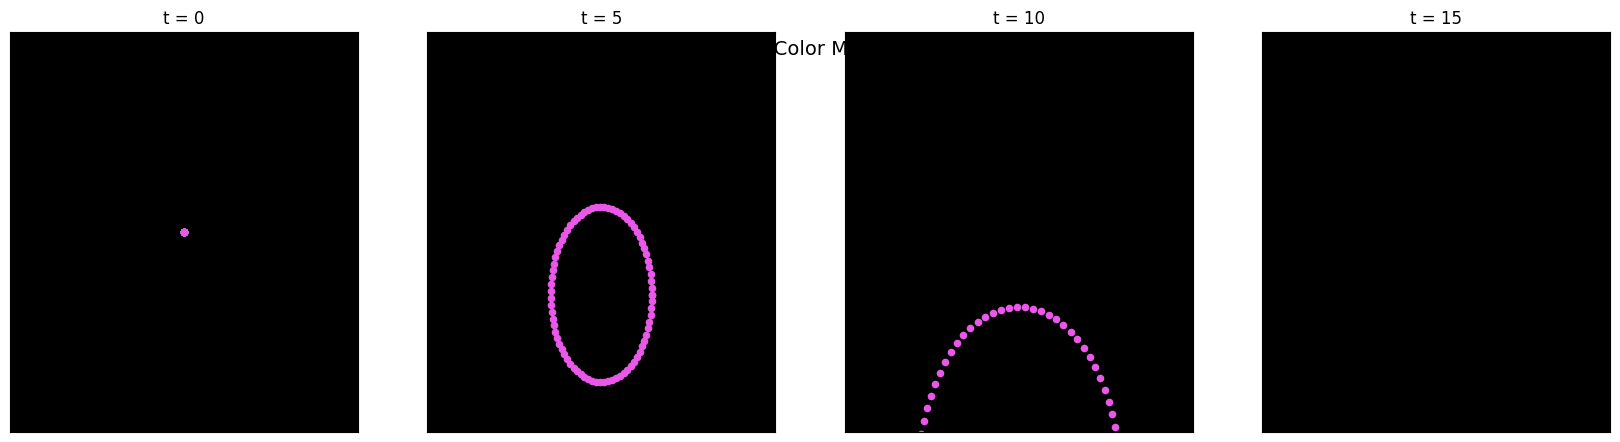

In [43]:
# Motion with a single fixed color (yellow)

n = 80 # Number of sparks

# Explosion Center
x0 = 0
y0 = 4

angles = np.linspace(0, 2 * np.pi, n)
speed = 3.5

# Initial positions
x = np.full(n, x0)
y = np.full(n, y0)

# Velocities
vx = np.cos(angles) * speed
vy = np.sin(angles) * speed

gravity = -0.1  # constant downward pull

# One random RGB color for the entire burst
base_color = np.random.rand(3)  # e.g. [0.4, 0.9, 0.2]

# Let's simulate motion for a few steps and plot snapshots
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Sparks in Rondom Color Moving With Gravity", fontsize=14)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.

for step, ax in enumerate(axes):
    ax.set_facecolor("black")
    ax.set_xlim(-6, 6)
    ax.set_ylim(0, 8)
    ax.set_xticks([])
    ax.set_yticks([])

    # Copy positions so each subplot shows a later time
    x_step = x + vx * 0.1 * (step * 5)
    y_step = y + vy * 0.1 * (step * 5) + 0.5 * gravity * (step * 5)**2

    ax.scatter(x_step, y_step, color=base_color, s=20)
    ax.set_title(f"t = {step * 5}")

plt.show()

Reflection Questions
- How is `base_color` different from `"yellow"`
- Why must RGB values be between `0` and `1`
- What changes visually when you re‑run the cell

### 2.4 Sparks With a Multi‑Color Palette

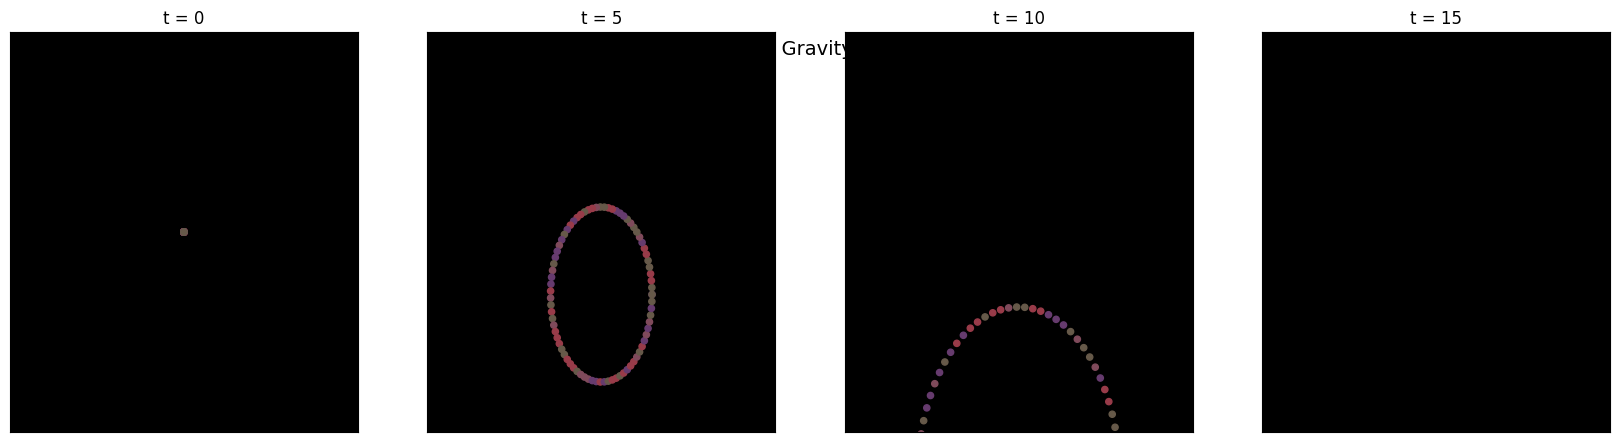

In [44]:
# Motion with a palette of related colors
n = 80 # Number of sparks

# Explosion Center
x0 = 0
y0 = 4

angles = np.linspace(0, 2 * np.pi, n)
speed = 3.5

# Initial positions
x = np.full(n, x0)
y = np.full(n, y0)

# Velocities
vx = np.cos(angles) * speed
vy = np.sin(angles) * speed

gravity = -0.1  # constant downward pull

# Base random color (R, G, B)
base_color = np.random.rand(3)

# Create a small palette of similar colors
palette = np.clip(np.array([
    base_color,
    base_color * np.array([1.2, 0.8, 0.8]),
    base_color * np.array([0.8, 1.2, 0.8]),
    base_color * np.array([0.8, 0.8, 1.2])
]), 0, 1)

# Assign each spark a random color from the palette
spark_colors = palette[np.random.randint(0, len(palette), n)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
fig.suptitle("Sparks Moving With Gravity (Multi‑Color Burst)", fontsize=14)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.

for step, ax in enumerate(axes):
    ax.set_facecolor("black")
    ax.set_xlim(-6, 6)
    ax.set_ylim(0, 8)
    ax.set_xticks([])
    ax.set_yticks([])

    t = step * 5

    x_step = x + vx * 0.1 * t
    y_step = y + vy * 0.1 * t + 0.5 * gravity * t**2

    ax.scatter(x_step, y_step, color=spark_colors, s=20)
    ax.set_title(f"t = {t}")

plt.show()


Reflection Questions
- Why do we use `np.clip` when creating the palette
- How does using a palette change the visual feel
- What role does randomness play in this step


### 2.4 Animate the multi-color burst (no trails yet)

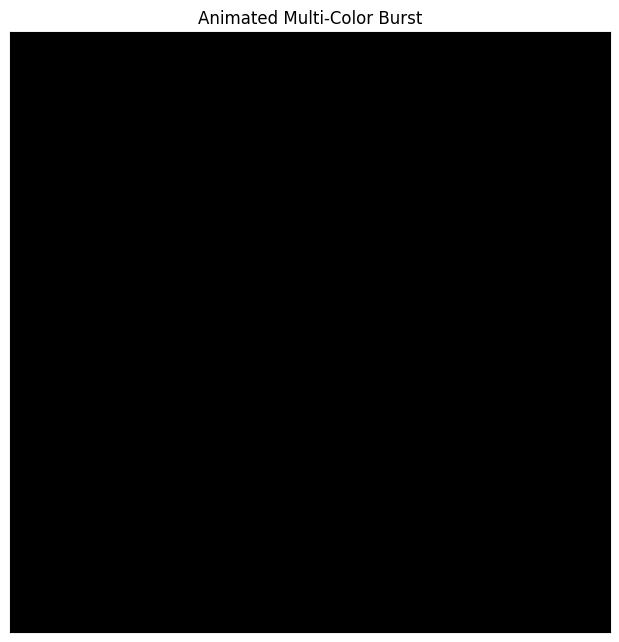

In [45]:
%matplotlib inline
from matplotlib.animation import FuncAnimation

n = 80 # Number of sparks

# Explosion Center
x0 = 0
y0 = 4

angles = np.linspace(0, 2 * np.pi, n)
speed = 3.5

x = np.full(n, x0)
y = np.full(n, y0)

vx = np.cos(angles) * speed
vy = np.sin(angles) * speed

gravity = -0.1

# Base random color (R, G, B)
base_color = np.random.rand(3)

# Create a small palette of similar colors
palette = np.clip(np.array([
    base_color,
    base_color * np.array([1.2, 0.8, 0.8]),
    base_color * np.array([0.8, 1.2, 0.8]),
    base_color * np.array([0.8, 0.8, 1.2])
]), 0, 1)

# Pick a random color from the palette for each spark
spark_colors = palette[np.random.randint(0, len(palette), n)]

# --- Animation setup ---
fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

scatter = ax.scatter([], [], s=30)

def update(frame):
    # Update positions
    global x, y, vy

    x = x + vx * 0.1
    y = y + vy * 0.1
    vy = vy + gravity

    # Fade over time
    alpha = max(0, (150 - frame) / 150) ** 1.2

    colors_with_alpha = np.hstack([
        spark_colors,
        np.full((n, 1), alpha)
    ])

    scatter.set_offsets(np.column_stack([x, y]))
    scatter.set_color(colors_with_alpha)

    return scatter,

plt.title("Animated Multi‑Color Burst")
ani = FuncAnimation(fig, update, frames=150, interval=40, blit=True)

HTML(ani.to_jshtml(default_mode ='loop'))


Reflection Questions
- How is this animation different from the earlier static snapshots
- Why does the firework fade out even though the colors stay the same
- What would happen if we removed the gravity term
- What visual effect does the alpha transparency create
- Why do we update vy every frame but not vx
These questions help students connect physics, color, and animation timing


### 2.5 Multi‑Color Burst With Trails (Single Firework)
Adding trails to each spark

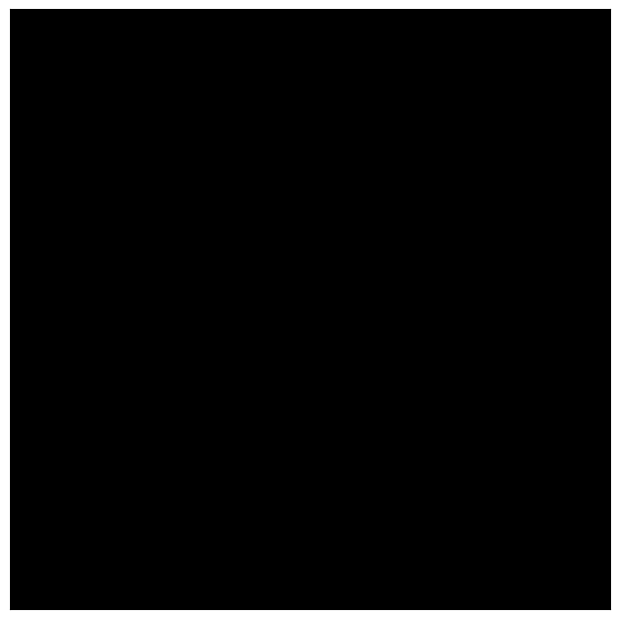

In [46]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

n = 80 # Number of sparks

# Explosion Center
x0 = 0
y0 = 4

angles = np.linspace(0, 2 * np.pi, n)
speed = 3.5

# Initial positions
x = np.full(n, x0)
y = np.full(n, y0)

# Velocities
vx = np.cos(angles) * speed
vy = np.sin(angles) * speed

gravity = -0.1

# Base random color (R, G, B)
base_color = np.random.rand(3)

# Create a small palette of similar colors
palette = np.clip(np.array([
    base_color,
    base_color * np.array([1.2, 0.8, 0.8]),
    base_color * np.array([0.8, 1.2, 0.8]),
    base_color * np.array([0.8, 0.8, 1.2])
]), 0, 1)

# Assign each spark a random color from the palette
spark_colors = palette[np.random.randint(0, len(palette), n)]

# --- NEW: Create empty trails ---
trails = [[] for _ in range(n)]   # one list per spark
max_trail_length = 15             # how many past positions to keep

# --- Animation setup ---
fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

# Scatter for sparks
scatter = ax.scatter([], [], s=30)

# One line per spark for trails
trail_lines = [
    ax.plot([], [], linewidth=1.2, alpha=0.7)[0]
    for _ in range(n)
]

def update(frame):
    global x, y, vy, trails

    # Update physics
    x = x + vx * 0.1
    y = y + vy * 0.1
    vy = vy + gravity

    # Fade over time
    alpha = max(0, (150 - frame) / 150) ** 1.2

    colors_with_alpha = np.hstack([
        spark_colors,
        np.full((n, 1), alpha)
    ])

    # Update spark positions
    scatter.set_offsets(np.column_stack([x, y]))
    scatter.set_color(colors_with_alpha)

    # --- Update trails ---
    for i in range(n):
        # Add current position to this spark's trail
        trails[i].append((x[i], y[i]))

        # Keep only the last N points
        if len(trails[i]) > max_trail_length:
            trails[i].pop(0)

        # Draw the trail
        if trails[i]:
            xs, ys = zip(*trails[i])
            trail_lines[i].set_data(xs, ys)
            trail_lines[i].set_color(np.append(spark_colors[i], alpha * 0.6))

    return [scatter] + trail_lines

ani = FuncAnimation(fig, update, frames=150, interval=40, blit=False)
HTML(ani.to_jshtml())

### 2.5 Create Reusable function for Single Burst

In [ ]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# ----------------------------------------------------
# Function 1: Create ONE firework object
# ----------------------------------------------------
def create_firework():
    """
    Creates a single firework particle system with:
      - positions
      - velocities
      - colors
      - trails
      - life counter
    """
    # Number of sparks
    n = random.randint(60, 120)

    # Explosion center
    x0 = random.uniform(-4, 4)
    y0 = random.uniform(2, 6)

    # Base random color
    base_color = np.random.rand(3)

    # Palette of related colors
    palette = np.clip(np.array([
        base_color,
        base_color * np.array([1.2, 0.8, 0.8]),
        base_color * np.array([0.8, 1.2, 0.8]),
        base_color * np.array([0.8, 0.8, 1.2])
    ]), 0, 1)

    # Velocity initialization
    angles = np.linspace(0, 2 * np.pi, n)
    speed = random.uniform(2.8, 4.2)

    vx = np.cos(angles) * speed
    vy = np.sin(angles) * speed

    spark_colors = palette[np.random.randint(0, len(palette), n)]

    fw = {}

    fw["x"] = np.full(n, x0)
    fw["y"] = np.full(n, y0)
    fw["vx"] = vx
    fw["vy"] = vy
    fw["colors"] = spark_colors
    fw["trail"] = [[] for _ in range(n)]
    fw["life"] = random.randint(90, 130)

    return fw

# ----------------------------------------------------
# Function 2: Update ONE firework
# ----------------------------------------------------
def update_firework(fw, gravity=-0.1, max_trail=15):
    """
    Updates physics, trails, and fading for a single firework.
    Does NOT touch Matplotlib artists.

    Returns:
        fw    (updated firework)
        alpha (fade value)
        dead  (True if finished)
    """

    # Physics
    fw["x"] += fw["vx"] * 0.1
    fw["y"] += fw["vy"] * 0.1
    fw["vy"] += gravity

    # Trails
    for i in range(len(fw["x"])):
        fw["trail"][i].append((fw["x"][i], fw["y"][i]))
        if len(fw["trail"][i]) > max_trail:
            fw["trail"][i].pop(0)

    # Life + fading
    fw["life"] -= 1
    alpha = max(0, fw["life"] / 130) ** 1.2
    dead = fw["life"] <= 0

    return fw, alpha, dead

def update_single_firework_scene(frame, fw, scatter, trail_lines):
    """
    Scene update for animating ONE firework.

    Responsibilities:
      - Call update_firework() to advance physics
      - Update scatter artist with new positions + alpha
      - Update trail line artists
      - Return updated artists for FuncAnimation
    """

    fw, alpha, dead = update_firework(fw)

    if dead:
        scatter.set_offsets(np.empty((0, 2)))
        for line in trail_lines:
            line.set_data([], [])
        return [scatter]

    # Update sparks
    scatter.set_offsets(np.column_stack([fw["x"], fw["y"]]))
    scatter.set_color(
        np.hstack([
            fw["colors"],
            np.full((len(fw["colors"]), 1), alpha)
        ])
    )

    # Update trails
    for i, line in enumerate(trail_lines):
        if fw["trail"][i]:
            xs, ys = zip(*fw["trail"][i])
            line.set_data(xs, ys)
            line.set_color(np.append(fw["colors"][i], alpha * 0.6))

    return [scatter] + trail_lines

# Animate
fw = create_firework()

fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

scatter = ax.scatter([], [], s=30)
trail_lines = [
    ax.plot([], [], linewidth=1.2, alpha=0.7)[0]
    for _ in range(len(fw["x"]))
]

ani = FuncAnimation(
    fig,
    lambda frame: update_single_firework_scene(frame, fw, scatter, trail_lines),
    frames=150,
    interval=40,
    blit=False
)

HTML(ani.to_jshtml())


## 3. Expanding The Fireworks Scene
### 3.1 Launching multiple fireworks and create a reusable function

In [ ]:
def update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob=0.05):
    """
    Scene update for animating MULTIPLE fireworks.

    Responsibilities:
      - Occasionally launch a new firework
      - Update physics for all fireworks
      - Update scatter + trail artists
      - Clear dead fireworks
      - Return all active scatter artists for FuncAnimation
    """

    # --- 1. Occasionally launch a new firework ---
    if random.random() < launch_prob:
        fw = create_firework()
        fireworks.append(fw)

        # Create artists for this firework
        scat = ax.scatter([], [], s=30)
        spark_scatters.append(scat)

        lines = [
            ax.plot([], [], linewidth=1.2, alpha=0.7)[0]
            for _ in range(len(fw["x"]))
        ]
        trail_lines.append(lines)

    # --- 2. Update all fireworks ---
    active_scatters = []

    for i, fw in enumerate(fireworks):
        scat = spark_scatters[i]
        lines = trail_lines[i]

        fw, alpha, dead = update_firework(fw)

        if dead:
            # Clear visuals
            scat.set_offsets(np.empty((0, 2)))
            for line in lines:
                line.set_data([], [])
            continue

        # Update sparks
        scat.set_offsets(np.column_stack([fw["x"], fw["y"]]))
        scat.set_color(
            np.hstack([
                fw["colors"],
                np.full((len(fw["colors"]), 1), alpha)
            ])
        )

        # Update trails
        for j, line in enumerate(lines):
            if fw["trail"][j]:
                xs, ys = zip(*fw["trail"][j])
                line.set_data(xs, ys)
                line.set_color(np.append(fw["colors"][j], alpha * 0.6))

        active_scatters.append(scat)

    return active_scatters


# ----------------------------------------------------
#  Animate a full scene with many fireworks
# ----------------------------------------------------

# Animation parameters
frames=100 # update cycles: compute and draw 200 separate moments.
interval=40 # how fast the animation plays: milliseconds between frames (40 = 25 fps)
launch_prob=0.05 # 5% chance each frame

# Storage for multiple fireworks
fireworks = []
spark_scatters = []
trail_lines = []

fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

ani = FuncAnimation(
    fig,
    lambda frame: update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob),
    frames=frames,
    interval=interval,
    blit=False
)

HTML(ani.to_jshtml())

### 3.2 Add some relalistic effect with random jitter

In [ ]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# ----------------------------------------------------
# Function 1: Create ONE firework object
# ----------------------------------------------------
def create_firework():
    """
    Creates a single firework particle system with:
      - positions
      - velocities
      - colors
      - trails
      - life counter
    """
    # Number of sparks
    n = random.randint(60, 120)

    # Explosion center
    x0 = random.uniform(-4, 4)
    y0 = random.uniform(2, 4)

    # Base random color
    base_color = np.random.rand(3)

    # Palette of related colors
    palette = np.clip(np.array([
        base_color,
        base_color * np.array([1.2, 0.8, 0.8]),
        base_color * np.array([0.8, 1.2, 0.8]),
        base_color * np.array([0.8, 0.8, 1.2])
    ]), 0, 1)

    # Velocity initialization
    angles = np.linspace(0, 2 * np.pi, n)
    speed = random.uniform(2.8, 4.2)

    vx = np.cos(angles) * speed
    vy = np.sin(angles) * speed

    # >>> [CHANGE] <<< 
    # Add a small random jitter to velocities
    vx += np.random.normal(0, 0.05, n)
    vy += np.random.normal(0, 0.05, n)

    spark_colors = palette[np.random.randint(0, len(palette), n)]

    fw = {}

    fw["x"] = np.full(n, x0)
    fw["y"] = np.full(n, y0)
    fw["vx"] = vx
    fw["vy"] = vy
    fw["colors"] = spark_colors
    fw["trail"] = [[] for _ in range(n)]
    fw["life"] = random.randint(90, 130)

    return fw

# ----------------------------------------------------
# Function 2: Update ONE firework
# ----------------------------------------------------
def update_firework(fw, gravity=-0.1, max_trail=15):
    """
    Updates physics, trails, and fading for a single firework.
    Does NOT touch Matplotlib artists.

    Returns:
        fw    (updated firework)
        alpha (fade value)
        dead  (True if finished)
    """

    # Physics
    fw["x"] += fw["vx"] * 0.1
    fw["y"] += fw["vy"] * 0.1
    fw["vy"] += gravity

    # >>> [CHANGE] <<< 
    # Add air drag to velocity 
    fw["vx"] *= 0.99
    fw["vy"] *= 0.99

    # >>> [CHANGE] <<< 
    # Add slight gravity variation with random.uniform
    fw["vy"] += gravity * random.uniform(0.9, 1.1)

    # Trails
    for i in range(len(fw["x"])):
        fw["trail"][i].append((fw["x"][i], fw["y"][i]))
        if len(fw["trail"][i]) > max_trail:
            fw["trail"][i].pop(0)

    # Life + fading
    fw["life"] -= 1
    alpha = max(0, fw["life"] / 130) ** 1.2
    dead = fw["life"] <= 0

    return fw, alpha, dead


In [ ]:
def update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob=0.05):
    """
    Scene update for animating MULTIPLE fireworks.

    Responsibilities:
      - Occasionally launch a new firework
      - Update physics for all fireworks
      - Update scatter + trail artists
      - Clear dead fireworks
      - Return all active scatter artists for FuncAnimation
    """

    # --- 1. Occasionally launch a new firework ---
    if random.random() < launch_prob:
        fw = create_firework()
        fireworks.append(fw)

        # Create artists for this firework
        scat = ax.scatter([], [], s=30)
        spark_scatters.append(scat)

        lines = [
            ax.plot([], [], linewidth=1.2, alpha=0.7)[0]
            for _ in range(len(fw["x"]))
        ]
        trail_lines.append(lines)

    # --- 2. Update all fireworks ---
    active_scatters = []

    for i, fw in enumerate(fireworks):
        scat = spark_scatters[i]
        lines = trail_lines[i]

        fw, alpha, dead = update_firework(fw)

        if dead:
            # Clear visuals
            scat.set_offsets(np.empty((0, 2)))
            for line in lines:
                line.set_data([], [])
            continue

        # Update sparks
        scat.set_offsets(np.column_stack([fw["x"], fw["y"]]))
        scat.set_color(
            np.hstack([
                fw["colors"],
                np.full((len(fw["colors"]), 1), alpha)
            ])
        )

        # Update trails
        for j, line in enumerate(lines):
            if fw["trail"][j]:
                xs, ys = zip(*fw["trail"][j])
                line.set_data(xs, ys)
                line.set_color(np.append(fw["colors"][j], alpha * 0.6))

        active_scatters.append(scat)

    return active_scatters


# ----------------------------------------------------
#  Animate a full scene with many fireworks
# ----------------------------------------------------

# Animation parameters
frames=200 # update cycles: compute and draw 200 separate moments.
interval=40 # how fast the animation plays: milliseconds between frames (40 = 25 fps)
launch_prob=0.05 # 5% chance each frame

# Storage for multiple fireworks
fireworks = []
spark_scatters = []
trail_lines = []

fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

ani = FuncAnimation(
    fig,
    lambda frame: update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob),
    frames=frames,
    interval=interval,
    blit=False
)

HTML(ani.to_jshtml())

Reflection Questions
- Why do we store all fireworks in a list instead of one variable
- What does random.random() < 0.05 control
- Why does each firework need its own scatter and trail lines
- How does the program know when to “remove” a firework
- What would happen if we increased the launch probability


### 3.2 Adding Text to the Fireworks Scene

In [ ]:
%matplotlib inline
# ---------------------------------------
# Scene setup
# ---------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 6)
ax.set_xticks([])
ax.set_yticks([])

text = ax.text(
    0, 3,
    "Happy New Year\n2026!",
    color="white",
    fontsize=36,
    fontweight="bold",
    fontstyle="italic",
    ha="center",
    va="center",
    alpha=1.0   
)

plt.show()

### 3.2 Add Animation Text to the Scene
Adding Random Color Change 

In [ ]:
# Step 6: Adding glowing "Happy New Year 2026!" text

%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# ---------------------------------------
# Scene setup
# ---------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

gravity = -0.1

fireworks = []
spark_scatters = []
trail_lines = []

# ---------------------------------------
# NEW: Add glowing text
# ---------------------------------------
text = ax.text(
    0, 3,
    "Happy New Year\n2026!",
    color="white",
    fontsize=36,
    fontweight="bold",
    fontstyle="italic",
    ha="center",
    va="center",
    alpha=0.0   # start invisible
)

# ---------------------------------------
# Animation update
# ---------------------------------------
def update(frame):

    # --- Animate text glow ---
    glow = 0.65 + 0.35 * np.sin(frame * 0.03)
    text.set_alpha(glow)

    # --- Animate text color cycling ---
    r = 0.8 + 0.2 * np.sin(frame * 0.02)
    g = 0.7 + 0.3 * np.sin(frame * 0.015 + 1)
    b = 0.5 + 0.5 * np.sin(frame * 0.01 + 2)
    text.set_color((r, g, b))


    return spark_scatters

ani = FuncAnimation(fig, update, frames=100, interval=40, blit=False)
HTML(ani.to_jshtml())

### 3.4 Ading Text to with Fireworks Scene

In [ ]:
def update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob=0.05):
    """
    Scene update for animating MULTIPLE fireworks.

    Responsibilities:
      - Occasionally launch a new firework
      - Update physics for all fireworks
      - Update scatter + trail artists
      - Clear dead fireworks
      - Return all active scatter artists for FuncAnimation
    """

    # >>>[CHANGE]<<<
    # ---------------------------------------
    # 0: Add glowing text
    # ---------------------------------------
    text = ax.text(
        0, 3.0,
        "Happy New Year\n2026!",
        color="white",
        fontsize=36,
        fontweight="bold",
        fontstyle="italic",
        ha="center",
        va="center",
        alpha=0.0   # start invisible
    )

    # --- Animate text glow ---
    glow = 0.65 + 0.35 * np.sin(frame * 0.03)
    text.set_alpha(glow)

    # --- Animate text color cycling ---
    r = 0.8 + 0.2 * np.sin(frame * 0.02)
    g = 0.7 + 0.3 * np.sin(frame * 0.015 + 1)
    b = 0.5 + 0.5 * np.sin(frame * 0.01 + 2)
    text.set_color((r, g, b))

    # --- 1. Occasionally launch a new firework ---
    if random.random() < launch_prob:
        fw = create_firework()
        fireworks.append(fw)

        # Create artists for this firework
        scat = ax.scatter([], [], s=30)
        spark_scatters.append(scat)

        lines = [
            ax.plot([], [], linewidth=1.2, alpha=0.7)[0]
            for _ in range(len(fw["x"]))
        ]
        trail_lines.append(lines)

    # --- 2. Update all fireworks ---
    active_scatters = []

    for i, fw in enumerate(fireworks):
        scat = spark_scatters[i]
        lines = trail_lines[i]

        fw, alpha, dead = update_firework(fw)

        if dead:
            # Clear visuals
            scat.set_offsets(np.empty((0, 2)))
            for line in lines:
                line.set_data([], [])
            continue

        # Update sparks
        scat.set_offsets(np.column_stack([fw["x"], fw["y"]]))
        scat.set_color(
            np.hstack([
                fw["colors"],
                np.full((len(fw["colors"]), 1), alpha)
            ])
        )

        # Update trails
        for j, line in enumerate(lines):
            if fw["trail"][j]:
                xs, ys = zip(*fw["trail"][j])
                line.set_data(xs, ys)
                line.set_color(np.append(fw["colors"][j], alpha * 0.6))

        active_scatters.append(scat)

    return active_scatters


# ----------------------------------------------------
#  Animate a full scene with many fireworks
# ----------------------------------------------------

# Animation parameters
frames=100 # update cycles: compute and draw 200 separate moments.
interval=40 # how fast the animation plays: milliseconds between frames (40 = 25 fps)
launch_prob=0.05 # 5% chance each frame

# Storage for multiple fireworks
fireworks = []
spark_scatters = []
trail_lines = []

fig, ax = plt.subplots(figsize=(6, 6))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # Fills the entire figure with the axes — no margins, no padding.

ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])


ani = FuncAnimation(
    fig,
    lambda frame: update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob),
    frames=frames,
    interval=interval,
    blit=False
)

HTML(ani.to_jshtml())

## 4. Assembling the full final animation

You’ve worked on gradually building componenets to this animation.
- Empty sky
- Static burst
- Motion + color
- Trails
- Multiple fireworks
- Glowing text
Now it’s time to assemble everything into one complete program.

In [ ]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import random

# ----------------------------------------------------
# Function 1: Create ONE firework object
# ----------------------------------------------------
def create_firework():
    """
    Creates a single firework particle system with:
      - positions
      - velocities
      - colors
      - trails
      - life counter
    """
    # Number of sparks
    n = random.randint(60, 120)

    # Explosion center
    x0 = random.uniform(-4, 4)
    y0 = random.uniform(2, 6)

    # Base random color
    base_color = np.random.rand(3)

    # Palette of related colors
    palette = np.clip(np.array([
        base_color,
        base_color * np.array([1.2, 0.8, 0.8]),
        base_color * np.array([0.8, 1.2, 0.8]),
        base_color * np.array([0.8, 0.8, 1.2])
    ]), 0, 1)

    # Velocity initialization
    angles = np.linspace(0, 2 * np.pi, n)
    speed = random.uniform(2.8, 4.2)

    vx = np.cos(angles) * speed
    vy = np.sin(angles) * speed

    # Add a small random jitter to velocities
    vx += np.random.normal(0, 0.05, n)
    vy += np.random.normal(0, 0.05, n)

    spark_colors = palette[np.random.randint(0, len(palette), n)]

    fw = {}

    fw["x"] = np.full(n, x0)
    fw["y"] = np.full(n, y0)
    fw["vx"] = vx
    fw["vy"] = vy
    fw["colors"] = spark_colors
    fw["trail"] = [[] for _ in range(n)]
    fw["life"] = random.randint(90, 130)

    return fw

# ----------------------------------------------------
# Function 2: Update ONE firework
# ----------------------------------------------------
def update_firework(fw, gravity=-0.1, max_trail=15):
    """
    Updates physics, trails, and fading for a single firework.
    Does NOT touch Matplotlib artists.

    Returns:
        fw    (updated firework)
        alpha (fade value)
        dead  (True if finished)
    """

    # Physics
    fw["x"] += fw["vx"] * 0.1
    fw["y"] += fw["vy"] * 0.1
    fw["vy"] += gravity

    # Add air drag to velocity 
    fw["vx"] *= 0.99
    fw["vy"] *= 0.99

    # Add slight gravity variation with random.uniform
    fw["vy"] += gravity * random.uniform(0.9, 1.1)

    # Trails
    for i in range(len(fw["x"])):
        fw["trail"][i].append((fw["x"][i], fw["y"][i]))
        if len(fw["trail"][i]) > max_trail:
            fw["trail"][i].pop(0)

    # Life + fading
    fw["life"] -= 1
    alpha = max(0, fw["life"] / 130) ** 1.2
    dead = fw["life"] <= 0

    return fw, alpha, dead

def update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob=0.05):
    """
    Scene update for animating MULTIPLE fireworks.

    Responsibilities:
      - Occasionally launch a new firework
      - Update physics for all fireworks
      - Update scatter + trail artists
      - Clear dead fireworks
      - Return all active scatter artists for FuncAnimation
    """

    # ---------------------------------------
    # 0: Add glowing text
    # ---------------------------------------
    text = ax.text(
        0, 3,
        "Happy New Year\n2026!",
        color="white",
        fontsize=36,
        fontweight="bold",
        fontstyle="italic",
        ha="center",
        va="center",
        alpha=0.0   # start invisible
    )

    # --- Animate text glow ---
    glow = 0.65 + 0.35 * np.sin(frame * 0.03)
    text.set_alpha(glow)

    # --- Animate text color cycling ---
    r = 0.8 + 0.2 * np.sin(frame * 0.02)
    g = 0.7 + 0.3 * np.sin(frame * 0.015 + 1)
    b = 0.5 + 0.5 * np.sin(frame * 0.01 + 2)
    text.set_color((r, g, b))

    # --- 1. Occasionally launch a new firework ---
    if random.random() < launch_prob:
        fw = create_firework()
        fireworks.append(fw)

        # Create artists for this firework
        scat = ax.scatter([], [], s=30)
        spark_scatters.append(scat)

        lines = [
            ax.plot([], [], linewidth=1.2, alpha=0.7)[0]
            for _ in range(len(fw["x"]))
        ]
        trail_lines.append(lines)

    # --- 2. Update all fireworks ---
    active_scatters = []

    for i, fw in enumerate(fireworks):
        scat = spark_scatters[i]
        lines = trail_lines[i]

        fw, alpha, dead = update_firework(fw)

        if dead:
            # Clear visuals
            scat.set_offsets(np.empty((0, 2)))
            for line in lines:
                line.set_data([], [])
            continue

        # Update sparks
        scat.set_offsets(np.column_stack([fw["x"], fw["y"]]))
        scat.set_color(
            np.hstack([
                fw["colors"],
                np.full((len(fw["colors"]), 1), alpha)
            ])
        )

        # Update trails
        for j, line in enumerate(lines):
            if fw["trail"][j]:
                xs, ys = zip(*fw["trail"][j])
                line.set_data(xs, ys)
                line.set_color(np.append(fw["colors"][j], alpha * 0.6))

        active_scatters.append(scat)

    return active_scatters


# ----------------------------------------------------
#  Animate a full scene with many fireworks
# ----------------------------------------------------

# Animation parameters
frames=100 # update cycles: compute and draw 200 separate moments.
interval=40 # how fast the animation plays: milliseconds between frames (40 = 25 fps)
launch_prob=0.05 # 5% chance each frame

# Storage for multiple fireworks
fireworks = []
spark_scatters = []
trail_lines = []

fig, ax = plt.subplots(figsize=(8, 8))
fig.subplots_adjust(left=0, right=1, top=1, bottom=0) # No Margins
ax.set_facecolor("black")
ax.set_xlim(-6, 6)
ax.set_ylim(0, 8)
ax.set_xticks([])
ax.set_yticks([])

ani = FuncAnimation(
    fig,
    lambda frame: update_multiple_fireworks_scene(frame, fireworks, spark_scatters, trail_lines, launch_prob),
    frames=frames,
    interval=interval,
    blit=False
)

HTML(ani.to_jshtml())

Reflection Questions
- How does organizing the code into functions and sections make it easier to understand
- Why is it helpful to build the animation step‑by‑step before assembling it
- What part of the code controls the look of the fireworks
- What part controls the physics
- What part controls the timing and animation


## 5. Saving the Animation as GIF/MP4

You’ve built a full fireworks animation — now it’s time to share it.
Matplotlib animations can be exported as:
- GIF → great for social media, messaging, and websites
- MP4 video → higher quality, smoother playback
To save animations, Matplotlib uses “writers” — small helper tools that convert frames into a file.
We’ll use:
- Pillow → for GIFs
- FFmpeg → for MP4 videos
Both are widely supported and easy to install.


### 5.1 Install the required Python Libraries

```
!pip install pillow
!pip install ffmpeg-python
```

If FFmpeg is not installed on your system, you may need to install it separately:
- Windows: `choco install ffmpeg`
- Mac: `brew install ffmpeg`
- Linux:`sudo apt install ffmpeg`



In [ ]:
# Uncomment below line to install withinin Notebook environemnt
#!pip install pillow ffmpeg-python

### 5.2 Saving as a GIF
This step may take longer time based on the frames

In [ ]:
ani.save("new_year_fireworks.gif", writer="pillow", fps=25)

### 5.3 Saving as an MP4 video (Optional)
Makesure to have `FFmpeg` installed in your system. Skip this step if you so not want to install `FFmpeg`.

In [ ]:
ani.save("new_year_fireworks.mp4", writer="ffmpeg", fps=25)

### 5.3 Showing the saved file inside the notebook 

##### GIF

In [ ]:
from IPython.display import Image
Image(filename="new_year_fireworks.gif")


#### MP4 video (Optional)

In [ ]:
# This will not work if teh saving as video fialed above
# Make sure you have `FFmpeg` installed in your system and retry.
from IPython.display import Video
Video("new_year_fireworks.mp4")

By coming into this stage of the Notebook now have:
- A complete fireworks animation
- A glowing New Year message
- Trails, physics, color cycling
- The ability to export and share their creation

---
**Attribution:** 
This tutorial includes AI‑assisted text and Python code generated with [Microsoft Copilot](https://copilot.microsoft.com), based on initial ideas developed by the author with step by step interactions with the AI tool in refining the content. All content was reviewed and edited before publication.

First Upload 2025-12-31 | Last update 2025-12-31 by Sumudu Tennakoon

<a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc-sa/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License</a>.